In [1]:
import pandas as pd

In [2]:
from homework03 import clean_data

In [3]:
df = pd.read_csv("./s3_data.txt", sep="\t")
df = clean_data(df)
df.head()

,date,VIX,rf,SP500,eurusd,FINANC,SPDIV
0,1999-01-31,26.25,0.361667,1248.77,NaN,237.56,16.283333
1,1999-02-28,27.88,0.370000,1246.58,-2.930822,240.45,16.366667
2,1999-03-31,23.26,0.370000,1281.66,-2.420890,249.18,16.450000
3,1999-04-30,25.07,0.357500,1334.76,-1.784055,265.72,16.450000
4,1999-05-31,25.39,0.375000,1332.07,-1.419111,250.69,16.450000


In [4]:
df.tail()

,date,VIX,rf,SP500,eurusd,FINANC,SPDIV
244,2019-05-31,18.71,0.195833,2854.71,-0.410165,319.21,55.70
245,2019-06-30,15.08,0.180833,2890.17,1.826484,340.17,56.08
246,2019-07-31,16.12,0.175000,2996.11,-2.611448,347.98,56.46
247,2019-08-31,18.98,0.162500,2897.50,-0.848682,330.34,56.84
248,2019-09-30,16.24,0.157500,2982.16,-0.755782,345.08,57.22


## Exercise 0

In [5]:
from homework03 import exercise_0_exess_returns

In [6]:
df = exercise_0_exess_returns(df)
df.head()

,date,VIX,rf,SP500,eurusd,FINANC,SPDIV,r_FINANC,r_SP500,excess_r_FINANC,excess_r_SP500
12,2000-01-31,24.95,0.443333,1425.59,-3.528126,229.99,16.713333,-0.033777,-0.002163,-0.038211,-0.006596
13,2000-02-29,23.37,0.462500,1388.87,-0.669620,205.00,16.736667,-0.108657,-0.025758,-0.113282,-0.030383
14,2000-03-31,24.11,0.474167,1442.21,-0.902302,242.19,16.760000,0.181415,0.038405,0.176673,0.033664
15,2000-04-30,26.20,0.471667,1461.36,-4.563056,234.32,16.740000,-0.032495,0.013278,-0.037212,0.008562
16,2000-05-31,23.65,0.482500,1418.48,2.862156,249.65,16.720000,0.065423,-0.029343,0.060598,-0.034168


## Exercise 1

In [7]:
from homework03 import exercise_1_AR, question_1_manual

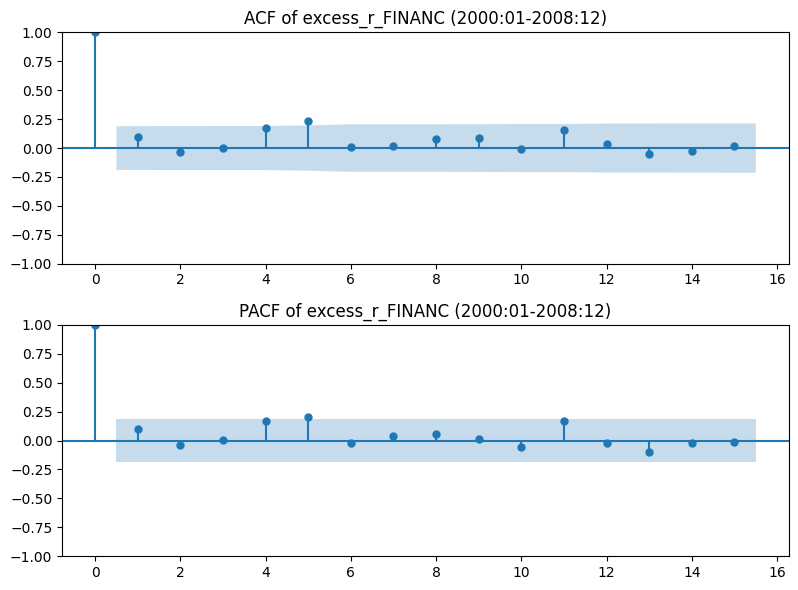

In [8]:
exercise_1_AR(df)

### Interpretation Exercise 1

The correlogram does not show a slow decay typical of a highly persistent process. In the ACF, the main individually significant spike is at lag 5. In the PACF, the most notable individually significant spike is also around lag 5. Overall, the series appears stationary with only limited short-run dependence rather than strong persistence.

#### Manual Computation 
Out of curiosity we implemented with the help of AI the ACF and PACF. This to see the actual implementation behind the library we used.

In [9]:
# acf_vals, pacf_vals = question_1_manual(df)

## Exercise 2

#### **REMARK**: Assumptions for Exercise 2:
For the selection of p for the AR(p) we did **NOT** demean y here (Ex. 2) even if this p is used in the following ex. 3. This because the exercise description does **NOT** state that we should use the demeaned y here in ex. 2. 

Therefore we will use **p = 11**, whether with the demeaned y we would get *p = 5*. 

In [10]:
from homework03 import exercise_2_p_selection

In [11]:
p = exercise_2_p_selection(df)
p

11

### Interpretation Exercise 2

According to the AIC, the selected order is \(p = 11\). This is not fully obvious from the correlogram alone, because the ACF and PACF do not display a very clear cutoff pattern. Hence, the main justification for choosing \(p = 11\) is the formal AIC criterion rather than a purely visual rule based on Exercise 1.

## Exercise 3

In [12]:
from homework03 import exercise_3_demeaned_ar

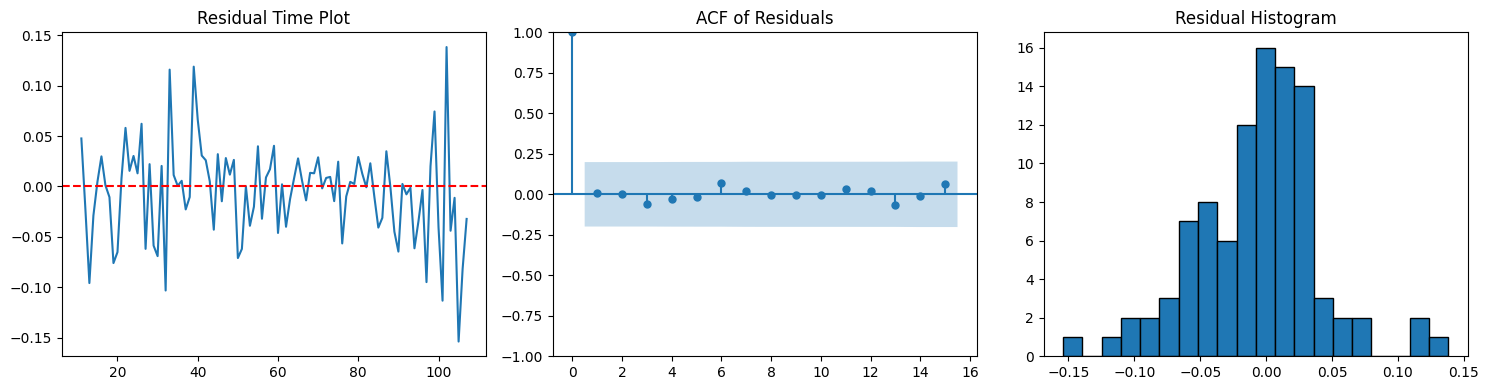

In [13]:
ar_model = exercise_3_demeaned_ar(df, p)

In [14]:
ar_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:        excess_r_FINANC   No. Observations:                  108
Model:                    AutoReg(11)   Log Likelihood                 157.706
Method:               Conditional MLE   S.D. of innovations              0.048
Date:                Tue, 24 Mar 2026   AIC                           -291.412
Time:                        21:34:16   BIC                           -260.515
Sample:                            11   HQIC                          -278.919
                                  108                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
excess_r_FINANC.L1      0.1981      0.098      2.026      0.043       0.006       0.390
excess_r_FINANC.L2     -0.1694      0.102     -1.667      0.095      -0.369       0.030
excess_r_FINANC.L3      0.1643      0.111      1.475      0.140      -0.054       0.383
excess_r_FINANC.L4      0.1146      0.112      1.024      0.306      -0.105       0.334
excess_r_FINANC.L5      0.3193      0.107      2.975      0.003       0.109       0.530
excess_r_FINANC.L6     -0.0132      0.116     -0.113      0.910      -0.241       0.215
excess_r_FINANC.L7      0.0762      0.114      0.670      0.503      -0.146       0.299
excess_r_FINANC.L8      0.1317      0.112      1.174      0.240      -0.088       0.352
excess_r_FINANC.L9      0.0149      0.107      0.140      0.889      -0.194       0.224
excess_r_FINANC.L10    -0.0850      0.103     -0.827      0.408      -0.287       0.117
excess_r_FINANC.L11     0.2524      0.104      2.416      0.016       0.048       0.457
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1            -1.1041           -0.3923j            1.1718           -0.4457
AR.2            -1.1041           +0.3923j            1.1718            0.4457
AR.3            -0.7117           -0.8304j            1.0937           -0.3628
AR.4            -0.7117           +0.8304j            1.0937            0.3628
AR.5            -0.0411           -1.0846j            1.0854           -0.2560
AR.6            -0.0411           +1.0846j            1.0854            0.2560
AR.7             0.4722           -1.0401j            1.1422           -0.1822
AR.8             0.4722           +1.0401j            1.1422            0.1822
AR.9             0.9994           -0.0000j            0.9994           -0.0000
AR.10            1.0535           -0.6785j            1.2531           -0.0911
AR.11            1.0535           +0.6785j            1.2531            0.0911
------------------------------------------------------------------------------
"""

### Interpretation Exercise 3

We estimated a demeaned AR(11) on 2000:01–2008:12. Among the 11 lags, only **lag 1** (p = 0.043), **lag 5** (p = 0.003) and **lag 11** (p = 0.016) are individually significant at 5%.

**Residual diagnostics:**
- The residual time plot shows no obvious pattern or trend. The residuals fluctuate around zero.
- The ACF of the residuals shows no significant autocorrelation, meaning the AR(11) has successfully captured the serial dependence.
- The histogram is roughly symmetric but shows some fat tails, which is expected for financial returns.
- The Ljung-Box test does not reject the null of no autocorrelation in the residuals, confirming the model is adequately specified.

### Exercise 4

In [15]:
from homework03 import exercise_4_forecast_2009_01

In [16]:
results = exercise_4_forecast_2009_01(df, ar_model, p)
results

{'forecast_date': '2009-01',
 'forecast_excess_r_FINANC': np.float64(-0.06719807151896902),
 'ci90_lower': np.float64(-0.14550487449350047),
 'ci90_upper': np.float64(0.011108731455562446)}

### Interpretation Exercise 4

The AR(11) forecast for 2009:01 is **−0.067** (−6.7%), with a 90% CI of [−0.146, +0.011]. The negative forecast is plausible given the financial crisis in late 2008. The CI includes zero, so the forecast is not significantly different from zero at the 10% level.

### Exercise 5

In [17]:
from homework03 import exercise_5_out_of_sample_forecast

In [18]:
forecasts_AR_model_df, rmse_AR_model = exercise_5_out_of_sample_forecast(df, p)
forecasts_AR_model_df

,date,forecast_excess_r_FINANC,actual_excess_r_FINANC,forecast_error,squared_error
0,2009-01-31,-0.067198,-0.265555,-0.198357,0.039345
1,2009-02-28,-0.179678,-0.184363,-0.004685,0.000022
2,2009-03-31,-0.068278,0.176405,0.244684,0.059870
3,2009-04-30,-0.049141,0.221472,0.270613,0.073231
4,2009-05-31,-0.092501,0.130870,0.223371,0.049895
...,...,...,...,...,...
124,2019-05-31,0.006285,-0.075745,-0.082031,0.006729
125,2019-06-30,0.005375,0.063854,0.058479,0.003420
126,2019-07-31,0.025612,0.021209,-0.004403,0.000019
127,2019-08-31,-0.032296,-0.052318,-0.020021,0.000401


In [19]:
rmse_AR_model

0.06990010628168816

### Interpretation Exercise 5

Using an expanding window from 2000:01–2008:12 onward, we forecast recursively until 2019:09. The **RMSE of the AR(11) is 0.070**. This serves as our benchmark for comparison with the factor model.

## Exercise 6

In [20]:
from homework03 import exercise_6_stationarity_tests

/Users/cyrilgabriele/Documents/School/00_Courses/03_FinancialEconometrics/02_Exercises/code/FinancialEconometrics/homeworks/homework03/homework03.py:275: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_usedlag, kpss_crit = kpss(


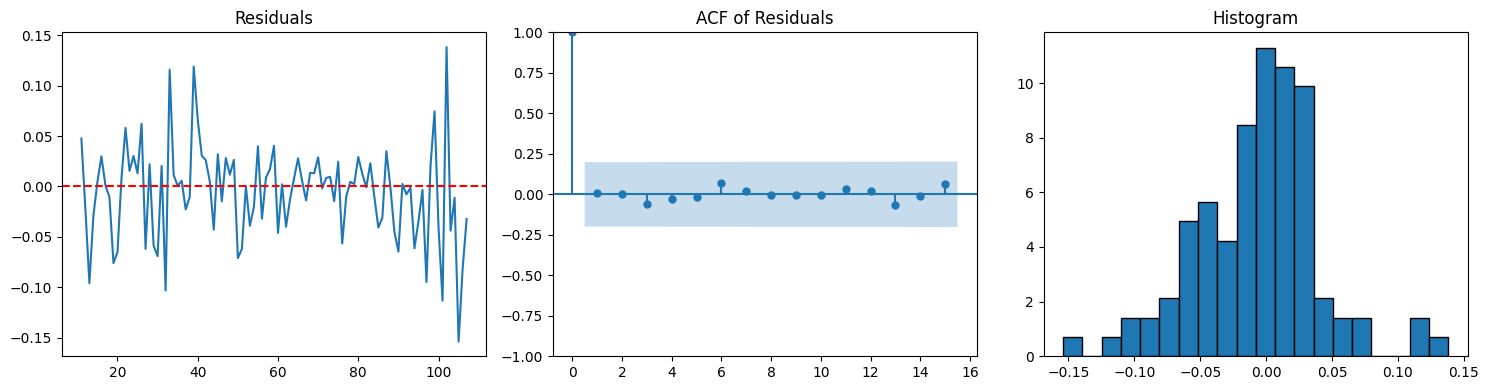

     lb_stat  lb_pvalue
10  1.054222   0.999781
15  2.197272   0.999945
20  5.646115   0.999298


,test,null_hypothesis,statistic,critical_value_1pct,reject_at_1pct,decision_rule
0,ADF,unit root / non-stationary,-3.094709,-3.459106,False,reject if statistic < critical value
1,KPSS,level-stationary around a constant,1.086608,0.739000,True,reject if statistic > critical value


In [21]:
df_extended, test_stats_df = exercise_6_stationarity_tests(df, ar_model)
test_stats_df

The extended df is used as well in ex. 7

In [22]:
df_extended.reset_index().head()

,index,date,VIX,rf,SP500,eurusd,FINANC,SPDIV,r_FINANC,r_SP500,excess_r_FINANC,excess_r_SP500,pd
0,12,2000-01-31,24.95,0.443333,1425.59,-3.528126,229.99,16.713333,-0.033777,-0.002163,-0.038211,-0.006596,4.446134
1,13,2000-02-29,23.37,0.462500,1388.87,-0.669620,205.00,16.736667,-0.108657,-0.025758,-0.113282,-0.030383,4.418644
2,14,2000-03-31,24.11,0.474167,1442.21,-0.902302,242.19,16.760000,0.181415,0.038405,0.176673,0.033664,4.454937
3,15,2000-04-30,26.20,0.471667,1461.36,-4.563056,234.32,16.740000,-0.032495,0.013278,-0.037212,0.008562,4.469322
4,16,2000-05-31,23.65,0.482500,1418.48,2.862156,249.65,16.720000,0.065423,-0.029343,0.060598,-0.034168,4.440736


### Interpretation Exercise 6

We computed pd = log(PD) and tested for stationarity using ADF and KPSS (constant, no trend).

| Test | H₀ | Statistic | Crit. Value (1%) | Decision |
|---|---|---|---|---|
| ADF | Unit root | −3.095 | −3.459 | Fail to reject → non-stationary |
| KPSS | Stationary | 1.087 | 0.739 | Reject → non-stationary |

Both tests agree: pd does not appear stationary in our sample. This is a known issue. The log price-dividend ratio is often assumed stationary in theory, but in finite samples it behaves like a near-unit-root process. We still use it as a predictor in Exercise 7, as is standard in the predictability literature.

*(The KPSS warning occurs because the p-value is below the smallest value in the lookup table, meaning the evidence against stationarity is very strong.)*

## Exercise 7

In [23]:
from homework03 import exercise_7_special_factor_model

In [24]:
ex_7_results = exercise_7_special_factor_model(df_extended)
ex_7_results

{'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x11994a390>,
 'forecast_date': '2009-01',
 'forecast_excess_r_FINANC': -0.03190333322526703,
 'ci95_lower': -0.16160627783399756,
 'ci95_upper': 0.09779961138346349}

In [25]:
ex_7_results["model"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        excess_r_FINANC   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.849
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0276
Time:                        21:34:16   Log-Likelihood:                 157.55
No. Observations:                 107   AIC:                            -305.1
Df Residuals:                     102   BIC:                            -291.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2222      0.122     -1.818      0.072      -0.465       0.020
lag_excess_r_SP500     0.1348      0.171      0.789      0.432      -0.204       0.474
lag_eurusd             0.0026      0.002      1.286      0.201      -0.001       0.007
lag_VIX               -0.0007      0.001     -0.810      0.420      -0.002       0.001
lag_pd                 0.0559      0.029      1.919      0.058      -0.002       0.114
==============================================================================
Omnibus:                        5.822   Durbin-Watson:                   2.103
Prob(Omnibus):                  0.054   Jarque-Bera (JB):                7.733
Skew:                          -0.214   Prob(JB):                       0.0209
Kurtosis:                       4.246   Cond. No.                         704.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation Exercise 7

We estimated the factor model on 2000:01–2008:12 and forecast 2009:01 using December 2008 predictor values.

| Quantity | Value |
|---|---|
| Forecast | **−0.032** (−3.2%) |
| 95% CI | [−0.096, +0.032] |

The confidence interval includes zero, so the forecast is not significant. The actual return in 2009:01 was about −26.6%. Both models heavily underestimated the crisis.

## Exercise 8

In [26]:
from homework03 import exercise_8_oos_factor_model

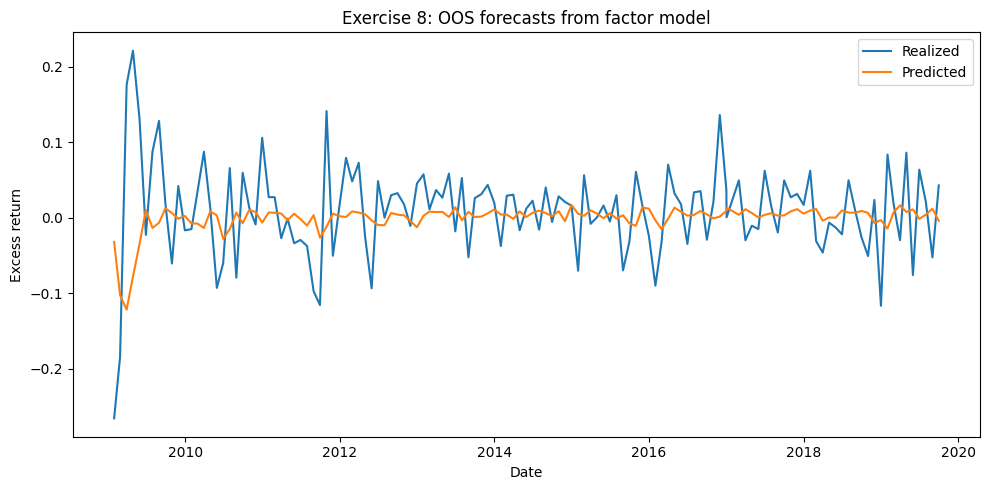

In [27]:
forecast_factor_model_df, rmse_factor_model = exercise_8_oos_factor_model(df_extended)

In [28]:
forecast_factor_model_df.head()

,date,forecast_excess_r_FINANC,actual_excess_r_FINANC,forecast_error,squared_error
0,2009-01-31,-0.031903,-0.265555,-0.233651,0.054593
1,2009-02-28,-0.102345,-0.184363,-0.082018,0.006727
2,2009-03-31,-0.121540,0.176405,0.297945,0.088771
3,2009-04-30,-0.077772,0.221472,0.299244,0.089547
4,2009-05-31,-0.034515,0.130870,0.165385,0.027352


In [29]:
rmse_factor_model

0.06802979943586882

### Interpretation Exercise 8

With the same expanding-window approach, the factor model's **RMSE is 0.068**, slightly below the AR(11)'s 0.070. The plot shows that predictions are much smoother than realized returns. The model captures the conditional mean but not the large shocks. Whether this small RMSE difference is significant will be tested in the next exercise.

## Exercise 9

In [30]:
from homework03 import exercise_9_diebold_mariano

Here for the Diebold-Mariano test the null hypothesis is defined as: 

H_0: E[d_t] = 0

In [31]:
dm_res = exercise_9_diebold_mariano(forecasts_AR_model_df, forecast_factor_model_df)
print("DM statistic:", dm_res["dm_stat"])
print("p-value:", dm_res["p_value"])
print("Better model:", dm_res["better_model_by_average_quadratic_loss"])
print("Conclusion:", dm_res["conclusion_5pct"])

DM statistic: 0.4763376250222722
p-value: 0.6338338644194779
Better model: Factor model
Conclusion: Do not reject equal forecast accuracy at 5%


### Interpretation Exercise 9

We performed a two-sided Diebold-Mariano test with quadratic loss comparing the AR(11) and factor model forecasts.

| Quantity | Value |
|---|---|
| DM statistic | 0.476 |
| p-value | 0.634 |

**Conclusion:** At the 5% level, we **do not reject** equal forecast accuracy. Although the factor model has a marginally lower RMSE, the difference is not statistically significant. The additional predictors (SP500, EUR/USD, VIX, pd) do not provide a significant forecasting improvement over the AR benchmark.